# Study 1 and 2 conclusions
---
### Optimisation parameters
- set perturb to a value it can't hit and it will do it's best without messing things up (time limit is never hit when at 60s)
- set exude to 0 and it will do its best without messing things up (time limit is never hit when at 60s)
- set lloyd convergence to a value it can't hit
- set llotd max iterations to 0 - no limit
- Then the quality of the optimisation is controlled by the combination of freeze bound and max time
    - Need to set freeze bound so that lloyd will exit with code 2 (can't improve anymore) within the given time limit!
---
### Cell count
- The combination of n_tets, min_size, and d0 control the number of tetrahedrons
- n_tets will be decided in the mesh independence study
- bigger d0 results in higher quality elements but explodes element count
- bones with very thin cartilage explode element count
- increasing min_size reduces element count but also results in n_tets not being met in those areas
- PLAN
    - do runs for subjects with the highest element counts and figure out what combos of d0 and h_min (n_test*min_size) give reasonable results
        - hopefully find value for n_tets=3 that gives good element quality for all but if not will have to ignore some the subjects will inflated element count.
    - use good params for optimisation

In [1]:
from phd_helpers.paramOptimisation.getInfo import get_params3d, get_runtimes, combine_metric_dfs, score_value
from phd_helpers.paths import get_info_df, get_subject_stl_path, get_mesh, avg_edge_length


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('../../../../MeshPipeline/outputs/ParamOptimisation/optimise3D') # path to parent of output_root in set_parameters
out_dir = Path('outputs/study2') # path dir to save outputs in

study_prefix = 'study2' # start of dir name of output_root in set_parameters
studies = ['a', 'b', 'c'] # individual study identifier (end of dir name of output_root in set_parameters)

In [3]:
get_params3d(root_dir, study_prefix, studies).to_csv(out_dir / 'params.csv', index=False)
get_runtimes(root_dir, study_prefix, studies).to_csv(out_dir / 'runtimes.csv', index=False)

In [4]:
import subprocess
path_computeMetrics = '../computeMetrics3d.py'
for study in studies[-1:]:
    study_dir = root_dir / (study_prefix + study)
    subprocess.run(["python", path_computeMetrics, study_dir, out_dir, 'full_params.json', study])

100%|██████████| 27/27 [02:22<00:00,  5.28s/it]


In [4]:
info = get_info_df('CMC')

df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, ['study2a-0a', 'study2b-0b', 'study2c-0c'])
df_qual['tets_vol'] = df_qual['total_tets'] / df_qual['total_vol']
#df_bone.to_csv(out_dir / 'df_bone.csv', index=False)
#df_cart.to_csv(out_dir / 'df_cart.csv', index=False)
#df_qual.to_csv(out_dir / 'df_qual.csv', index=False)

df_run = pd.read_csv(out_dir / 'runtimes.csv')
df_param = pd.read_csv(out_dir / 'params.csv')
df_param

,sub,bone,run_id,cgal_params.sizing_field.d0,cgal_params.lloyd.freeze_bound,cgal_params.perturb.sliver_bound
0,14873R,tpm,0-0a,3,0.00500,0
1,14873R,tpm,1-0a,3,0.00500,20
2,14873R,tpm,2-0a,3,0.00500,30
3,14873R,tpm,3-0a,3,0.00250,0
4,14873R,tpm,4-0a,3,0.00250,20
...,...,...,...,...,...,...
480,50021R,mc1,22-0c,5,0.00250,20
481,50021R,mc1,23-0c,5,0.00250,30
482,50021R,mc1,24-0c,5,0.00125,0
483,50021R,mc1,25-0c,5,0.00125,20


In [44]:
bone = 'tpm'

d_metric2 = 'max'
d_metric1 = '99'
iteration_cart = 'orig'
iteration_bone = 'orig'
loc = 'i'

qual_metric = '99%'
qual_part = 'cart'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'bone_{iteration_bone}_d{loc}_{d_metric2}',
    f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'cart_{iteration_cart}_d{loc}_{d_metric2}',

    # quality (keep high)
    f'{qual_part}_min_angle_{qual_metric}',
    f'{qual_part}_scaled_jacobian_{qual_metric}',
    f'{qual_part}_min_angle_worst',
    f'{qual_part}_scaled_jacobian_worst',

    # cell count (keep low)
    'total_tets'

]


bone_df = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_d{loc}_{d_metric1}', f'{iteration_bone}_d{loc}_{d_metric2}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_d{loc}_{d_metric1}': f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'{iteration_bone}_d{loc}_{d_metric2}': f'bone_{iteration_bone}_d{loc}_{d_metric2}'
})

cart_df = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_d{loc}_{d_metric1}', f'{iteration_cart}_d{loc}_{d_metric2}']
].rename(columns={
    f'{iteration_cart}_d{loc}_{d_metric1}': f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'{iteration_cart}_d{loc}_{d_metric2}': f'cart_{iteration_cart}_d{loc}_{d_metric2}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        f'{qual_part}_min_angle_{qual_metric}',
        f'{qual_part}_scaled_jacobian_{qual_metric}',
        f'{qual_part}_min_angle_worst',
        f'{qual_part}_scaled_jacobian_worst',
        f'{qual_part}_aspect_ratio_{qual_metric}',
        f'{qual_part}_radius_ratio_{qual_metric}',
        f'{qual_part}_aspect_ratio_worst',
        f'{qual_part}_radius_ratio_worst',
        'total_tets',
        'tets_vol'
    ]
]

df = (
    bone_df
    .merge(cart_df, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)

df = df[df['bone']==bone]

14873R - Average edge length: 0.4424 mm
14874R - Average edge length: 0.4418 mm
50037L - Average edge length: 0.3688 mm
50016L - Average edge length: 0.3665 mm
22306R - Average edge length: 0.4384 mm
50008L - Average edge length: 0.3718 mm
14548R - Average edge length: 0.3605 mm
50045R - Average edge length: 0.3666 mm
50021R - Average edge length: 0.3692 mm


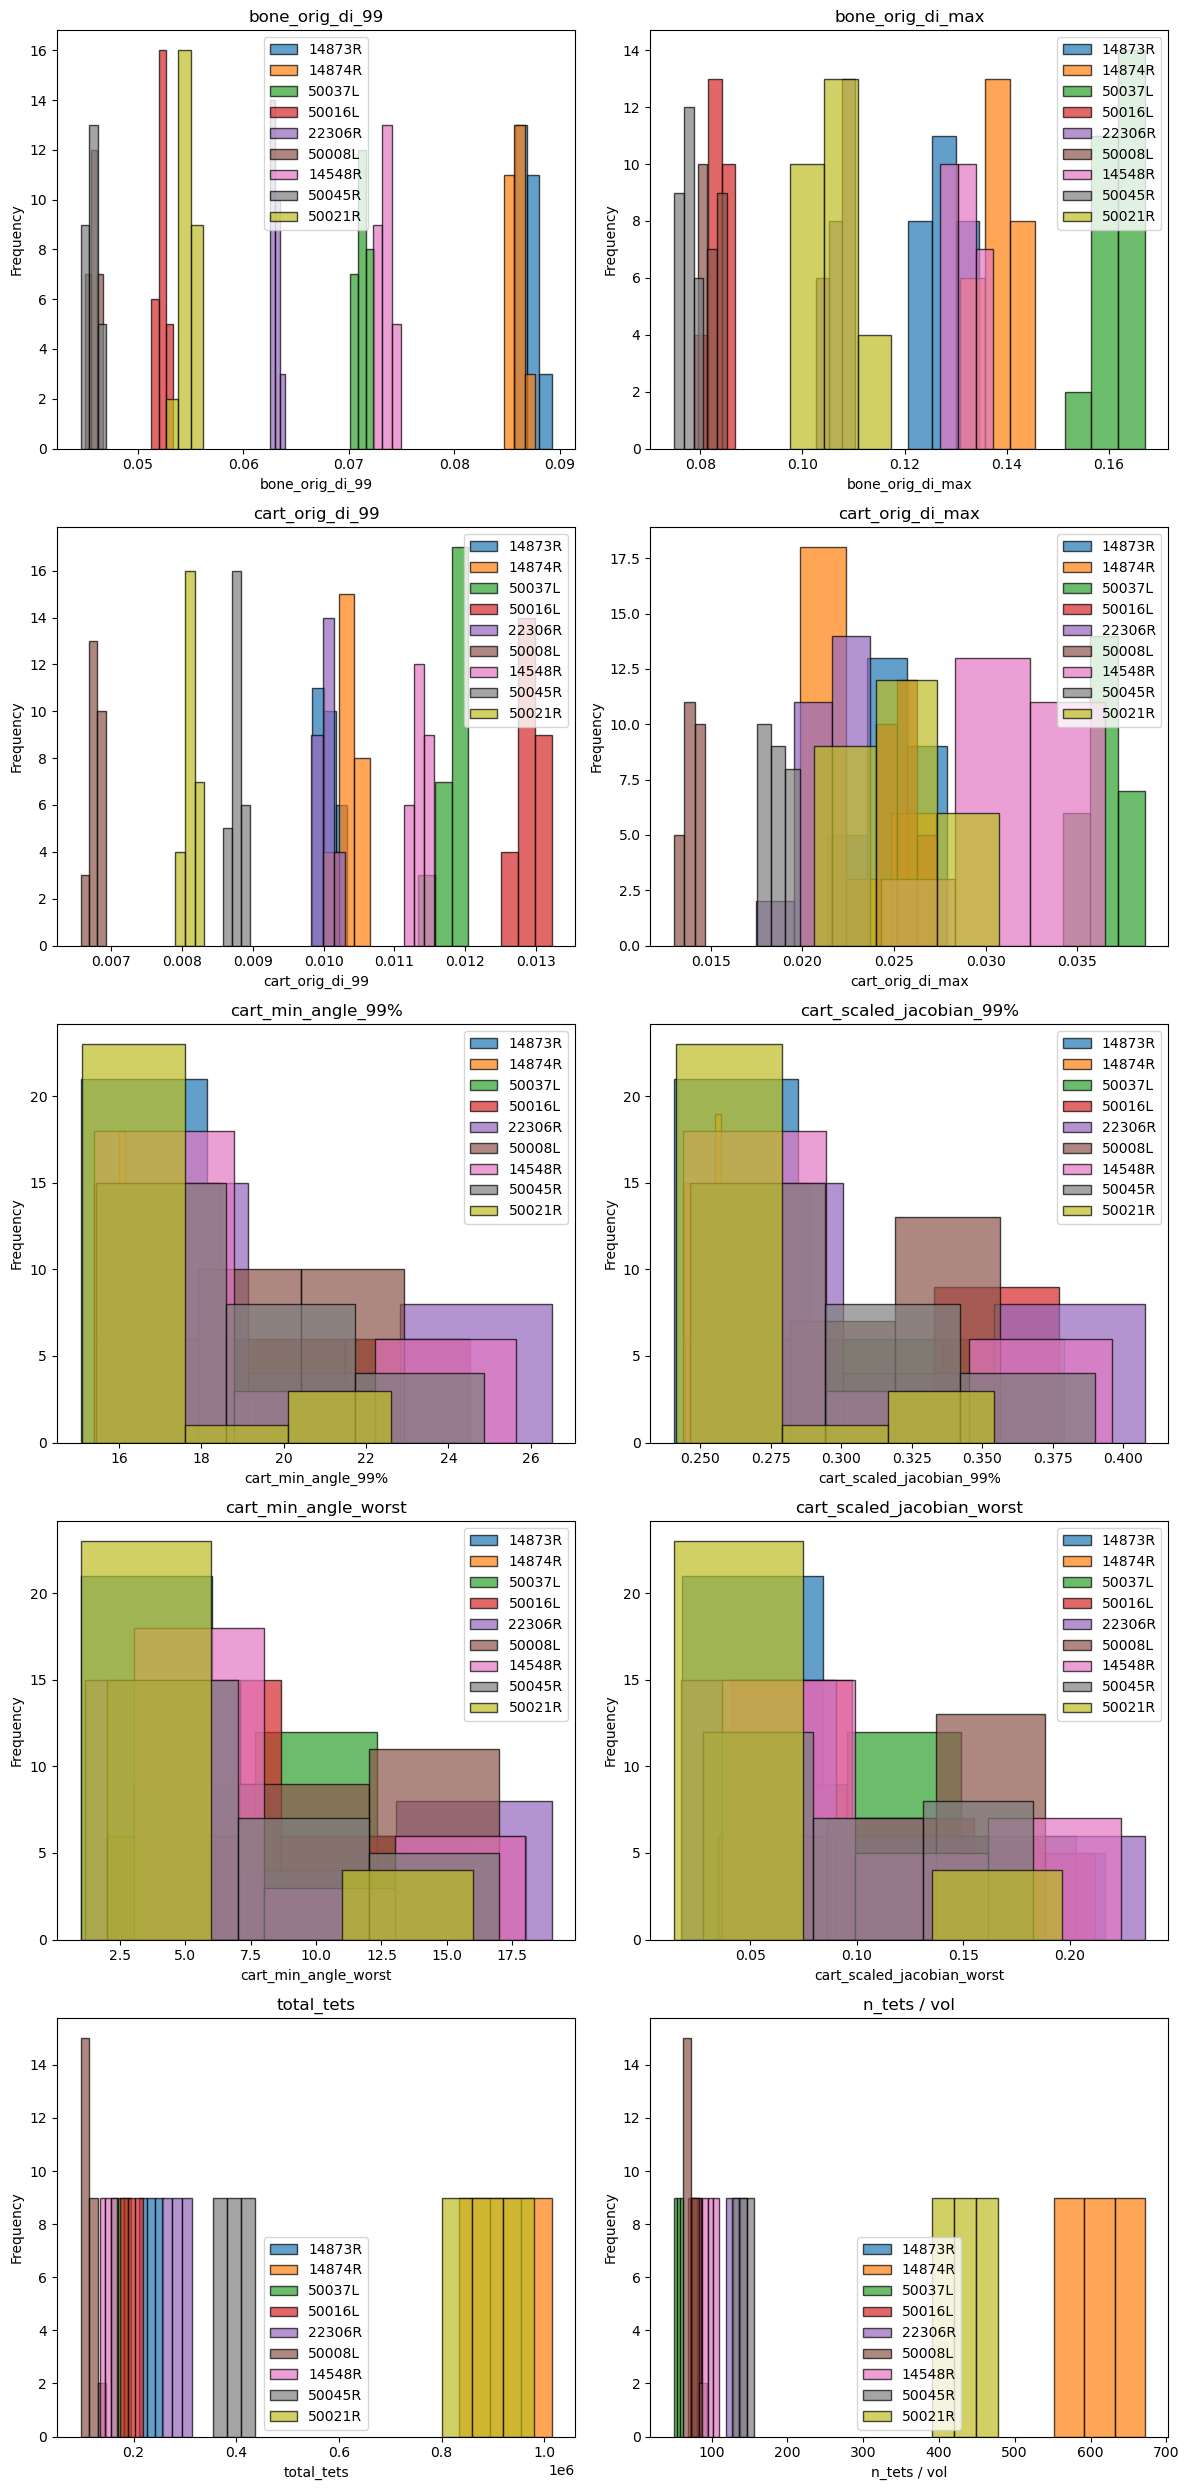

In [45]:
fig, ax = plt.subplots(5, 2, figsize=(12, 25))
ax = ax.flatten()


for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    orig_vol = info[(info['subject']==int(subject)) & (info['side']==side)]['tpm_volume'].values
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    print(f"{sub} - Average edge length: {L:.4f} mm")

    sub_df = df[df['sub']==sub]
    bins = round(len(sub_df) / 10)
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        ax[i].legend()

    #ax[-1].hist(100 * (sub_df['remesh3d_vol'].values - orig_vol) / orig_vol, bins=bins, edgecolor='black', alpha=0.7)
    ax[-1].hist(sub_df['tets_vol'], bins=bins, edgecolor='black', alpha=0.7, label=sub)
    ax[-1].set_title("n_tets / vol")
    ax[-1].set_xlabel("n_tets / vol")
    ax[-1].set_ylabel('Frequency')
    ax[-1].legend()

plt.tight_layout()
plt.show()

### 14548 an 50045 have worse worst values even though d0 was larger?
 - Below compares the identical runs except for the fact exude was disabled for study2


 #### Exude comparison
 - Appears that exude disabled gives significantly worse results than exude enabled and Exude 0 gives the best results
 - But these were the worst results 
 - Exude of 20 in study 1 gave same worst angles as exude 0 for freeze 0.0025 but the 99.9% was much worse - got sacrificed to try and hit higher goal but didn't actually improve the worst value just made the 99.9% drop significantly.
 - Exude of 0 gave by far the best result.

In [25]:
sub = '14548R'
bone = 'tpm'

df_param_1 = pd.read_csv('outputs/study1/params.csv')
df_param_1 = df_param_1[(df_param_1['sub']==sub) & (df_param_1['bone']==bone)].reset_index()
df_qual_1 = pd.read_csv('outputs/study1/df_qual.csv')
df_qual_1 = df_qual_1[(df_qual_1['sub']==sub) & (df_qual_1['bone']==bone)].reset_index()

df_param_2 = pd.read_csv('outputs/study2/params.csv')
df_param_2 = df_param_2[(df_param_2['sub']==sub) & (df_param_2['bone']==bone)].reset_index()
df_qual_2 = pd.read_csv('outputs/study2/df_qual.csv')
df_qual_2 = df_qual_2[(df_qual_2['sub']==sub) & (df_qual_2['bone']==bone)].reset_index()

df_param_1a = df_param_1[ (df_param_1['cgal_params.lloyd.convergence']==0.0025) & (df_param_1['cgal_params.sizing_field.d0']==4) & (df_param_1['cgal_params.perturb.sliver_bound']==20)]
df_qual_1a = df_qual_1[(df_param_1['cgal_params.lloyd.convergence']==0.0025) & (df_param_1['cgal_params.sizing_field.d0']==4) & (df_param_1['cgal_params.perturb.sliver_bound']==20)]

df_param_2a = df_param_2[ (df_param_2['cgal_params.sizing_field.d0']==4) & (df_param_2['cgal_params.perturb.sliver_bound']==20)]
df_qual_2a = df_qual_2[ (df_param_2['cgal_params.sizing_field.d0']==4) & (df_param_2['cgal_params.perturb.sliver_bound']==20)]

/var/folders/md/chz9snx91svc73k94gsj2m7m0000gn/T/ipykernel_59756/3337110191.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_qual_1 = df_qual_1[(df_qual_1['sub']==sub) & (df_qual_1['bone']==bone)].reset_index()
/var/folders/md/chz9snx91svc73k94gsj2m7m0000gn/T/ipykernel_59756/3337110191.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_qual_2 = df_qual_2[(df_qual_2['sub']==sub) & (df_qual_2['bone']==bone)].reset_index()


In [26]:
df_param_1a

,index,sub,bone,run_id,cgal_params.sizing_field.d0,cgal_params.lloyd.convergence,cgal_params.lloyd.freeze_bound,cgal_params.perturb.sliver_bound,cgal_params.exude.sliver_bound
141,141,14548R,tpm,60-0b,4,0.0025,0.0100,20,0
142,142,14548R,tpm,61-0b,4,0.0025,0.0100,20,10
143,143,14548R,tpm,62-0b,4,0.0025,0.0100,20,20
150,150,14548R,tpm,69-0b,4,0.0025,0.0050,20,0
151,151,14548R,tpm,70-0b,4,0.0025,0.0050,20,10
152,152,14548R,tpm,71-0b,4,0.0025,0.0050,20,20
159,159,14548R,tpm,78-0b,4,0.0025,0.0025,20,0
160,160,14548R,tpm,79-0b,4,0.0025,0.0025,20,10
161,161,14548R,tpm,80-0b,4,0.0025,0.0025,20,20


In [27]:
df_param_2a

,index,sub,bone,run_id,cgal_params.sizing_field.d0,cgal_params.lloyd.freeze_bound,cgal_params.perturb.sliver_bound
10,333,14548R,tpm,10-0c,4,0.00500,20
13,336,14548R,tpm,13-0c,4,0.00250,20
16,339,14548R,tpm,16-0c,4,0.00125,20


In [32]:
cols = ['cart_inner_min_angle_worst', 'cart_inner_min_angle_99%', 'cart_inner_min_angle_99.9%']
df_qual_1a[cols]

,cart_inner_min_angle_worst,cart_inner_min_angle_99%,cart_inner_min_angle_99.9%
141,12.982030,29.480264,20.604004
142,10.036805,18.314585,11.287073
143,12.982030,25.133699,20.008989
150,14.931296,31.280463,22.057531
151,10.024022,20.061586,11.616626
152,14.931296,26.486681,20.305907
159,15.551632,32.909037,22.916338
160,15.001467,23.671064,16.529207
161,15.551632,27.801017,20.574422


In [29]:
df_qual_2a[cols]

,cart_inner_min_angle_worst,cart_inner_min_angle_99%
10,4.259780,16.545800
13,15.001467,23.671064
16,4.008082,18.646800


# Scores

In [39]:
#d_weight = 1
q_weight = 1 
t_weight = 2

chosen_metrics = {
    #'bone_orig_di_max': {
    #    'ideal': 0.15,
    #    'acceptable': 0.25,
    #    'weight': d_weight
    #},
    #'cart_orig_di_max': {
    #    'ideal': 0.025,
    #    'acceptable': 0.05,
    #    'weight': d_weight
    #},

    #f'{qual_part}_min_angle_99%': {
    #    'ideal': 30,
    #    'acceptable': 15,
    #    'weight': q_weight
    #},
    f'{qual_part}_min_angle_worst': {
        'ideal': 15,
        'acceptable': 10,
        'weight': q_weight
    },
    #f'{qual_part}_scaled_jacobian_99%': {
    #    'ideal': 0.4,
    #    'acceptable': 0.3,
    #    'weight': q_weight
    #},
    f'{qual_part}_scaled_jacobian_worst': {
        'ideal': 0.3,
        'acceptable': 0.2,
        'weight': q_weight
    },

    #f'{qual_part}_aspect_ratio_99%': {
    #    'ideal': 3,
    #    'acceptable': 4,
    #    'weight': q_weight
    #},
    f'{qual_part}_aspect_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },
    #f'{qual_part}_radius_ratio_99%': {
    #    'ideal': 3,
    #    'acceptable': 4,
    #    'weight': q_weight
    #},
    f'{qual_part}_radius_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },


    'tets_vol': {
        'ideal': 120,
        'acceptable': 150,
        'weight': t_weight
    }
}

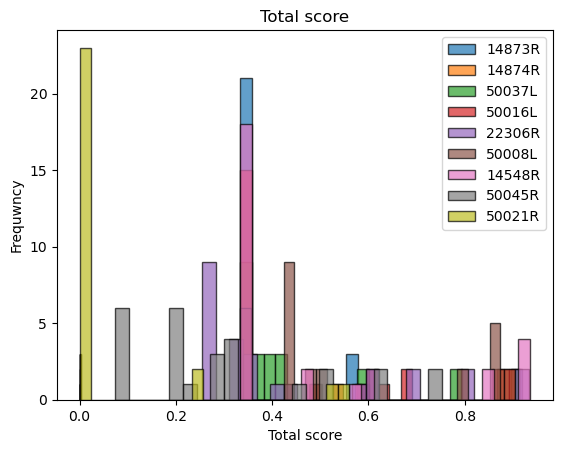

In [40]:
decay = 4
linear_floor = 0.5
total_weight = sum([w['weight'] for w in chosen_metrics.values()])

df_score = df[['sub', 'bone', 'run_id']].copy()
total = 0
for metric, bounds in chosen_metrics.items():
    score = score_value(df[metric], bounds['ideal'], bounds['acceptable'], linear_floor, decay)
    df_score[metric] = score
    total += score * bounds['weight'] / total_weight
df_score['total'] = total
df_score['rank_within_case'] = (
    df_score.groupby(['sub', 'bone'])['total']
    .rank(ascending=False, method='average')
)


fig, ax = plt.subplots()

subs = df_score['sub'].unique()
for sub in subs:
    sub_df = df_score[df_score['sub'] == sub]

    ax.hist(sub_df['total'], bins=round(len(df_score)/10), edgecolor='black', alpha=0.7, label=sub)

    ax.set_title("Total score")
    ax.set_xlabel('Total score')
    ax.set_ylabel('Frequwncy')
    ax.legend()

In [41]:
# Merge with params

df_score = df_score.sort_values('total', ascending=False)

df_score_param = df_score.merge(
    df_param,
    on=['sub', 'bone', 'run_id'],
    how='left'
)

In [43]:
df_score_param

,sub,bone,run_id,cart_min_angle_worst,cart_scaled_jacobian_worst,cart_aspect_ratio_worst,cart_radius_ratio_worst,tets_vol,total,rank_within_case,cgal_params.sizing_field.d0,cgal_params.lloyd.freeze_bound,cgal_params.perturb.sliver_bound
0,14548R,tpm,26-0c,1.000000,0.619840,1.000000e+00,1.000000e+00,1.000000e+00,0.936640,1.5,5,0.00125,30
1,14548R,tpm,25-0c,1.000000,0.619840,1.000000e+00,1.000000e+00,1.000000e+00,0.936640,1.5,5,0.00125,20
2,14548R,tpm,2-0c,1.000000,0.615059,1.000000e+00,1.000000e+00,1.000000e+00,0.935843,3.5,3,0.00500,30
3,14548R,tpm,1-0c,1.000000,0.615059,1.000000e+00,1.000000e+00,1.000000e+00,0.935843,3.5,3,0.00500,20
4,22306R,tpm,1-0b,1.000000,0.599611,1.000000e+00,1.000000e+00,1.000000e+00,0.933268,1.5,3,0.00500,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,50021R,tpm,3-0c,0.000827,0.000559,2.275712e-47,2.548754e-42,3.284642e-15,0.000231,23.0,3,0.00250,0
238,50021R,tpm,5-0c,0.000829,0.000534,1.423994e-45,4.588614e-42,3.265979e-15,0.000227,24.0,3,0.00250,30
239,50021R,tpm,11-0c,0.000381,0.000340,2.486738e-95,9.525124e-211,1.099351e-17,0.000120,25.5,4,0.00500,30
240,50021R,tpm,10-0c,0.000381,0.000340,2.486738e-95,9.525124e-211,1.099351e-17,0.000120,25.5,4,0.00500,20


In [42]:
# Best accross all subjects

df_grouped_rank = (
    df_score_param
    .groupby(df_param.columns[3:].to_list(), dropna=False)
    .agg(
        mean_rank=('rank_within_case', 'mean'),
        median_rank=('rank_within_case', 'median'),
        best_rank=('rank_within_case', 'min'),
        n_runs=('rank_within_case', 'size')
    )
    .reset_index()
    .sort_values('mean_rank')
)
df_grouped_rank

,cgal_params.sizing_field.d0,cgal_params.lloyd.freeze_bound,cgal_params.perturb.sliver_bound,mean_rank,median_rank,best_rank,n_runs
22,5,0.00250,20,9.666667,8.0,3.0,9
23,5,0.00250,30,10.111111,8.5,4.0,9
19,5,0.00125,20,10.666667,15.0,1.5,9
20,5,0.00125,30,11.111111,15.0,1.5,9
7,3,0.00500,20,11.944444,13.0,1.5,9
25,5,0.00500,20,12.222222,8.0,1.0,9
21,5,0.00250,0,12.333333,11.0,5.5,9
18,5,0.00125,0,13.000000,15.0,2.0,9
26,5,0.00500,30,13.444444,11.0,3.5,9
11,4,0.00125,30,13.611111,17.0,1.5,9


In [ ]:
# Best accross all subjects

df_grouped_rank = (
    df_score_param
    .groupby(df_param.columns[3:].to_list(), dropna=False)
    .agg(
        mean_rank=('rank_within_case', 'mean'),
        median_rank=('rank_within_case', 'median'),
        best_rank=('rank_within_case', 'min'),
        n_runs=('rank_within_case', 'size')
    )
    .reset_index()
    .sort_values('mean_rank')
)
df_grouped_rank

,cgal_params.sizing_field.d0,cgal_params.lloyd.freeze_bound,cgal_params.perturb.sliver_bound,mean_rank,median_rank,best_rank,n_runs
10,4,0.00125,20,10.361111,9.50,1.0,18
13,4,0.00250,20,11.638889,11.50,1.0,18
25,5,0.00500,20,12.166667,10.00,1.0,18
14,4,0.00250,30,12.222222,14.75,1.5,18
11,4,0.00125,30,12.277778,13.25,1.5,18
26,5,0.00500,30,12.638889,11.50,1.0,18
19,5,0.00125,20,12.833333,13.75,1.5,18
23,5,0.00250,30,13.000000,9.50,1.5,18
22,5,0.00250,20,13.000000,10.75,1.5,18
16,4,0.00500,20,13.500000,12.50,1.5,18
